# 03c — Gradient Boosting (Benchmark Model)

## Role of This Model

Gradient Boosting is the second benchmark model, typically the strongest performer on tabular data.

Unlike Random Forest which builds trees in **parallel**, Gradient Boosting builds them **sequentially** — each tree corrects the errors of the previous one. This often yields better precision but at the cost of longer training time and more sensitivity to hyperparameters.

| Property | Random Forest | Gradient Boosting |
|---|---|---|
| Tree building | Parallel | Sequential |
| Bias-variance | Low variance | Low bias |
| Speed | Faster | Slower |
| Typical AUC | Good | Best |

> **Reminder:** We use this model to answer whether complexity improves *decision quality* — not just accuracy. If improvement over Logistic Regression is marginal, the simpler model wins.

---

## 1. Imports and Data Loading

In [1]:
import sys
sys.path.append('../../src')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

from modeling import (
    split_data,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    print_metrics_table,
    save_model,
)

df = pd.read_csv('../../data/featured_churn.csv')

print('Loaded featured data.')
print('Shape:', df.shape)

Loaded featured data.
Shape: (7032, 32)


---
## 2. Train / Test Split

In [2]:
X_train, X_test, y_train, y_test = split_data(df)

print(f'Training set : {X_train.shape[0]} rows  |  Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test set     : {X_test.shape[0]} rows  |  Churn rate: {y_test.mean()*100:.1f}%')

Training set : 5625 rows  |  Churn rate: 26.6%
Test set     : 1407 rows  |  Churn rate: 26.6%


---
## 3. Train Gradient Boosting

Note: `GradientBoostingClassifier` does not support `class_weight` directly.  
Instead we use `sample_weight` during fitting — passing balanced weights computed from the training labels.

In [3]:
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights to handle imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=100,       # number of boosting stages
    learning_rate=0.1,      # contribution of each tree
    max_depth=3,            # shallow trees reduce overfitting
    random_state=42
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)
print('Model trained successfully.')

Model trained successfully.


---
## 4. Evaluation

In [4]:
metrics = evaluate_model(gb_model, X_test, y_test)
print_metrics_table(metrics, model_name='Gradient Boosting')


  Gradient Boosting — Evaluation Results
  ROC-AUC     : 0.8404  ◄ primary
  Recall      : 0.7968  ◄ business priority
  Precision   : 0.5017
  F1          : 0.6157
  Accuracy    : 0.7356



---
## 5. Confusion Matrix

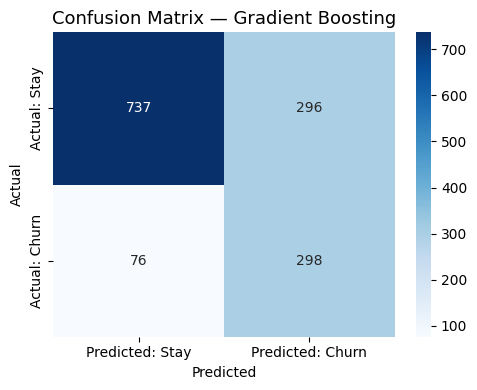

  True Positives  (caught churners):  298
  False Negatives (missed churners):  76  ← business cost
  False Positives (wrong alerts):     296
  True Negatives  (correct stays):    737


In [5]:
plot_confusion_matrix(gb_model, X_test, y_test, model_name='Gradient Boosting')

---
## 6. ROC Curve

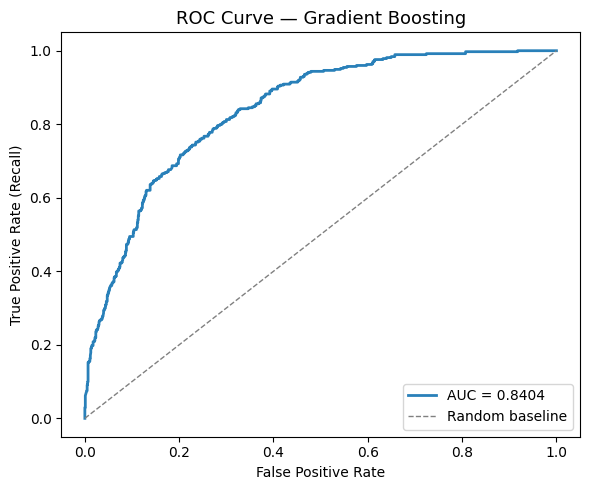

In [6]:
plot_roc_curve(gb_model, X_test, y_test, model_name='Gradient Boosting')

---
## 7. Feature Importance

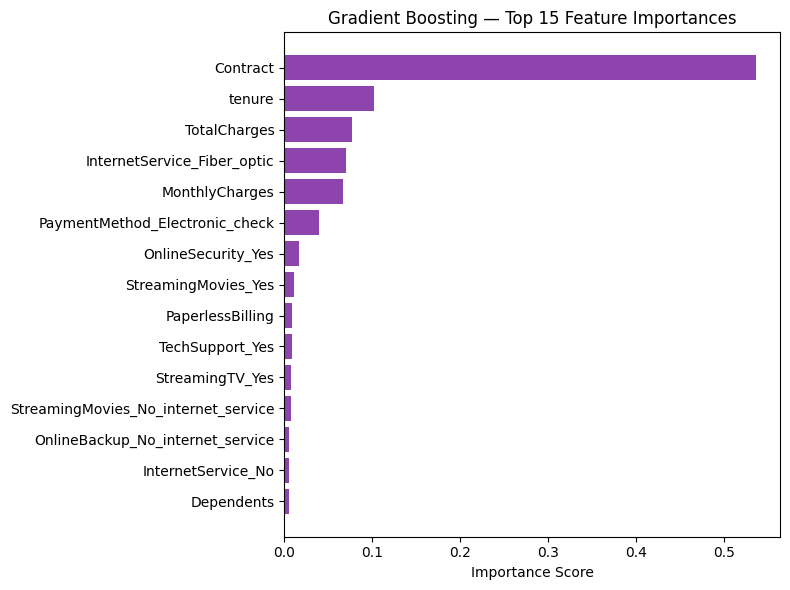


Top 10 most important features:
                       Feature  Importance
                      Contract    0.537318
                        tenure    0.101612
                  TotalCharges    0.077115
   InternetService_Fiber_optic    0.070315
                MonthlyCharges    0.066564
PaymentMethod_Electronic_check    0.039591
            OnlineSecurity_Yes    0.016831
           StreamingMovies_Yes    0.010662
              PaperlessBilling    0.008756
               TechSupport_Yes    0.008483


In [7]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='#8e44ad')
ax.set_title('Gradient Boosting — Top 15 Feature Importances', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(importance_df.head(10).to_string(index=False))

---
## 8. Save Model

In [9]:
save_model(gb_model, 'gradient_boosting', folder='../../models')
print('Gradient Boosting model saved. Proceed to 04_evaluation.ipynb')

Model saved to: ../../models\gradient_boosting.pkl
Gradient Boosting model saved. Proceed to 04_evaluation.ipynb


---
## Summary

Gradient Boosting completes the three-model benchmark suite:

| Model | Complexity | Interpretability |
|---|---|---|
| Logistic Regression | Low | High |
| Random Forest | Medium | Medium |
| Gradient Boosting | High | Low |

The full comparison and business conclusions are in `04_evaluation.ipynb`.